# Clasificación de Sentimiento con BOW/TF-IDF

___

# Corpus IMDB50K

In [190]:
import pandas as pd

df = pd.read_csv('IMDB50K.csv')

___

# Limpieza del corpus 

## Primera visualización

In [191]:
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


## Limpieza

### - Balance de clases

In [192]:
df["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Ya se encuentran balanceadas

### - Limpieza del texto

Función de limpieza

In [193]:
import re

def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'<.*?>', '', texto)
    texto = re.sub(r'[^\w\s]', '', texto)
    texto = re.sub(r'\d+', ' ', texto)
    return texto

In [194]:
df['cleaned_reviews'] = df['review'].apply(limpiar_texto)

___

# División train/test

In [195]:
from sklearn.model_selection import train_test_split

X = df['cleaned_reviews']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(f"Entrenamiento: {len(y_train)} filas")
print(f"Prueba: {len(y_test)} filas")

Entrenamiento: 37500 filas
Prueba: 12500 filas


___

# Creación de features

## BOW

In [196]:
from sklearn.feature_extraction.text import CountVectorizer

def bow_vectorizer(features, ngram):
    return CountVectorizer(
        stop_words='english',
        max_features=features,
        ngram_range=ngram
    )

X_bow = {}

for ngram_range in [(1, 1), (1, 2), (1, 3)]:
    vectorizer = bow_vectorizer(15000, ngram_range)
    X_bow[f"ngram-{ngram_range[0]}_{ngram_range[1]}"] = {
        "train": vectorizer.fit_transform(X_train),
        "test": vectorizer.transform(X_test)
    }

## TF-IDF

In [197]:
from sklearn.feature_extraction.text import TfidfVectorizer

def tf_idf(features, ngram):
    return TfidfVectorizer(
        stop_words='english',
        max_features=features,
        ngram_range=ngram
    )

X_tfidf = {}

for ngram_range in [(1, 1), (1, 2), (1, 3)]:
    tfidf = tf_idf(20000, ngram_range)
    X_tfidf[f"ngram-{ngram_range[0]}_{ngram_range[1]}"] = {
        "train": tfidf.fit_transform(X_train),
        "test": tfidf.transform(X_test)
    }

___

# Entrenamiento de modelos

In [198]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

### - Función para imprimir resultados

In [199]:
def print_results(model, predictions):
    print(f"Resultados para {model}:")
    for features, ngrams in predictions.items():
        print(f"\n\n----- {features} -----")
        for ranges, results in ngrams.items():
            print(f"N-gram range: {ranges}")
            print(f"Accuracy: {results['accuracy_test']:.4f}")
            print(f"F1 Score: {results['f1_test']:.4f}")
            print("Confusion Matrix:")
            print(results['confusion_matrix_test'])
            print("\n")

## Logistic Regression

In [200]:
lr = LogisticRegression(max_iter=1000)

predictions_lr = {
    'bow': {},
    'tfidf': {},
}

for ngram, matrix in X_bow.items():
    lr.fit(X_bow[ngram]["train"], y_train)

    pred_train = lr.predict(X_bow[ngram]["train"])
    pred_test = lr.predict(X_bow[ngram]["test"])

    predictions_lr['bow'][ngram] = {
        "pred_train": pred_train,
        "pred_test": pred_test,
        "accuracy_test": accuracy_score(y_test, pred_test),
        "f1_test": f1_score(y_test, pred_test, average='weighted'),
        "confusion_matrix_test": confusion_matrix(y_test, pred_test),
        "classification_report_test": classification_report(y_test, pred_test)
    }

for ngram, matrix in X_tfidf.items():
    lr.fit(X_tfidf[ngram]["train"], y_train)

    pred_train = lr.predict(X_tfidf[ngram]["train"])
    pred_test = lr.predict(X_tfidf[ngram]["test"])

    predictions_lr['tfidf'][ngram] = {
        "pred_train": pred_train,
        "pred_test": pred_test,
        "accuracy_test": accuracy_score(y_test, pred_test),
        "f1_test": f1_score(y_test, pred_test, average='weighted'),
        "confusion_matrix_test": confusion_matrix(y_test, pred_test),
        "classification_report_test": classification_report(y_test, pred_test)
    }

In [201]:
print_results("Logistic Regression", predictions_lr)

Resultados para Logistic Regression:


----- bow -----
N-gram range: ngram-1_1
Accuracy: 0.8754
F1 Score: 0.8754
Confusion Matrix:
[[5450  800]
 [ 757 5493]]


N-gram range: ngram-1_2
Accuracy: 0.8793
F1 Score: 0.8793
Confusion Matrix:
[[5478  772]
 [ 737 5513]]


N-gram range: ngram-1_3
Accuracy: 0.8779
F1 Score: 0.8779
Confusion Matrix:
[[5482  768]
 [ 758 5492]]




----- tfidf -----
N-gram range: ngram-1_1
Accuracy: 0.8945
F1 Score: 0.8945
Confusion Matrix:
[[5525  725]
 [ 594 5656]]


N-gram range: ngram-1_2
Accuracy: 0.8974
F1 Score: 0.8974
Confusion Matrix:
[[5543  707]
 [ 575 5675]]


N-gram range: ngram-1_3
Accuracy: 0.8971
F1 Score: 0.8971
Confusion Matrix:
[[5551  699]
 [ 587 5663]]




## Naive Bayes

In [202]:
nb = MultinomialNB()

predictions_nb = {
    'bow': {},
    'tfidf': {},
}

for ngram, matrix in X_bow.items():
    nb.fit(X_bow[ngram]["train"], y_train)

    pred_train = nb.predict(X_bow[ngram]["train"])
    pred_test = nb.predict(X_bow[ngram]["test"])

    predictions_nb['bow'][ngram] = {
        "pred_train": pred_train,
        "pred_test": pred_test,
        "accuracy_test": accuracy_score(y_test, pred_test),
        "f1_test": f1_score(y_test, pred_test, average='weighted'),
        "confusion_matrix_test": confusion_matrix(y_test, pred_test),
        "classification_report_test": classification_report(y_test, pred_test)
    }

for ngram, matrix in X_tfidf.items():
    nb.fit(X_tfidf[ngram]["train"], y_train)

    pred_train = nb.predict(X_tfidf[ngram]["train"])
    pred_test = nb.predict(X_tfidf[ngram]["test"])

    predictions_nb['tfidf'][ngram] = {
        "pred_train": pred_train,
        "pred_test": pred_test,
        "accuracy_test": accuracy_score(y_test, pred_test),
        "f1_test": f1_score(y_test, pred_test, average='weighted'),
        "confusion_matrix_test": confusion_matrix(y_test, pred_test),
        "classification_report_test": classification_report(y_test, pred_test)
    }

In [203]:
print_results("Naive Bayes", predictions_nb)

Resultados para Naive Bayes:


----- bow -----
N-gram range: ngram-1_1
Accuracy: 0.8488
F1 Score: 0.8488
Confusion Matrix:
[[5372  878]
 [1012 5238]]


N-gram range: ngram-1_2
Accuracy: 0.8558
F1 Score: 0.8558
Confusion Matrix:
[[5319  931]
 [ 872 5378]]


N-gram range: ngram-1_3
Accuracy: 0.8562
F1 Score: 0.8562
Confusion Matrix:
[[5314  936]
 [ 862 5388]]




----- tfidf -----
N-gram range: ngram-1_1
Accuracy: 0.8602
F1 Score: 0.8602
Confusion Matrix:
[[5408  842]
 [ 905 5345]]


N-gram range: ngram-1_2
Accuracy: 0.8695
F1 Score: 0.8695
Confusion Matrix:
[[5335  915]
 [ 716 5534]]


N-gram range: ngram-1_3
Accuracy: 0.8699
F1 Score: 0.8699
Confusion Matrix:
[[5326  924]
 [ 702 5548]]




## Random Forest

In [204]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

predictions_rf = {
    'bow': {},
    'tfidf': {},
}

for ngram, matrix in X_bow.items():
    rf.fit(X_bow[ngram]["train"], y_train)

    pred_train = rf.predict(X_bow[ngram]["train"])
    pred_test = rf.predict(X_bow[ngram]["test"])

    predictions_rf['bow'][ngram] = {
        "pred_train": pred_train,
        "pred_test": pred_test,
        "accuracy_test": accuracy_score(y_test, pred_test),
        "f1_test": f1_score(y_test, pred_test, average='weighted'),
        "confusion_matrix_test": confusion_matrix(y_test, pred_test),
        "classification_report_test": classification_report(y_test, pred_test)
    }

for ngram, matrix in X_tfidf.items():
    rf.fit(X_tfidf[ngram]["train"], y_train)

    pred_train = rf.predict(X_tfidf[ngram]["train"])
    pred_test = rf.predict(X_tfidf[ngram]["test"])

    predictions_rf['tfidf'][ngram] = {
        "pred_train": pred_train,
        "pred_test": pred_test,
        "accuracy_test": accuracy_score(y_test, pred_test),
        "f1_test": f1_score(y_test, pred_test, average='weighted'),
        "confusion_matrix_test": confusion_matrix(y_test, pred_test),
        "classification_report_test": classification_report(y_test, pred_test)
    }

In [205]:
print_results("Random Forest", predictions_rf)

Resultados para Random Forest:


----- bow -----
N-gram range: ngram-1_1
Accuracy: 0.8532
F1 Score: 0.8532
Confusion Matrix:
[[5377  873]
 [ 962 5288]]


N-gram range: ngram-1_2
Accuracy: 0.8560
F1 Score: 0.8560
Confusion Matrix:
[[5385  865]
 [ 935 5315]]


N-gram range: ngram-1_3
Accuracy: 0.8527
F1 Score: 0.8527
Confusion Matrix:
[[5342  908]
 [ 933 5317]]




----- tfidf -----
N-gram range: ngram-1_1
Accuracy: 0.8523
F1 Score: 0.8523
Confusion Matrix:
[[5391  859]
 [ 987 5263]]


N-gram range: ngram-1_2
Accuracy: 0.8550
F1 Score: 0.8550
Confusion Matrix:
[[5385  865]
 [ 947 5303]]


N-gram range: ngram-1_3
Accuracy: 0.8563
F1 Score: 0.8563
Confusion Matrix:
[[5403  847]
 [ 949 5301]]




___

# Optimización de hiperparámetros

### - Función para imprimir resultados

In [206]:
def print_results(model, predictions):
    print(f"Resultados para {model}:")
    for features, ngrams in predictions.items():
        print(f"\n\n----- {features} -----")
        for ranges, results in ngrams.items():
            print(f"N-gram range: {ranges}")
            print(f"Best params: {results['best_params']}")
            print(f"Best score: {results['best_score']}")
            print("\n")

### - Función de optimización

In [207]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint

def optimization(model, param_dist, X_train, n_iter=30):
    search = RandomizedSearchCV(
        model, 
        param_distributions=param_dist, 
        n_iter=n_iter, 
        cv=3, 
        scoring='f1_weighted', 
        n_jobs=-1,
        verbose=1,
        random_state=42
    )
    search.fit(X_train, y_train)
    return search.best_params_, search.best_score_

## Logistic Regression

In [208]:
lr_params = {
    'C': loguniform(1e-4, 1e2),
    'solver': ['liblinear']
}

optimization_lr = {
    "bow": {},
    "tfidf": {}
}

for ngram, matrix in X_bow.items():
    best_params, best_score = optimization(lr, lr_params, matrix["train"])
    optimization_lr["bow"][ngram] = {
        "best_params": best_params,
        "best_score": best_score
    }

for ngram, matrix in X_tfidf.items():
    best_params, best_score = optimization(lr, lr_params, matrix["train"])
    optimization_lr["tfidf"][ngram] = {
        "best_params": best_params,
        "best_score": best_score
    }

Fitting 3 folds for each of 30 candidates, totalling 90 fits


Fitting 3 folds for each of 30 candidates, totalling 90 fits
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Fitting 3 folds for each of 30 candidates, totalling 90 fits


In [209]:
print_results("Logistic Regression", optimization_lr)

Resultados para Logistic Regression:


----- bow -----
N-gram range: ngram-1_1
Best params: {'C': np.float64(0.054502936945582565), 'solver': 'liblinear'}
Best score: 0.8799590566631386


N-gram range: ngram-1_2
Best params: {'C': np.float64(0.039054412752107935), 'solver': 'liblinear'}
Best score: 0.8833157058969342


N-gram range: ngram-1_3
Best params: {'C': np.float64(0.054502936945582565), 'solver': 'liblinear'}
Best score: 0.8832362334639244




----- tfidf -----
N-gram range: ngram-1_1
Best params: {'C': np.float64(2.465832945854912), 'solver': 'liblinear'}
Best score: 0.8864066584899263


N-gram range: ngram-1_2
Best params: {'C': np.float64(2.465832945854912), 'solver': 'liblinear'}
Best score: 0.8899825222144608


N-gram range: ngram-1_3
Best params: {'C': np.float64(2.465832945854912), 'solver': 'liblinear'}
Best score: 0.8901165455786929




## Naive Baiyes

In [210]:
nb_params = {
    'alpha': loguniform(1e-2, 10) 
}

optimization_nb = {
    "bow": {},
    "tfidf": {}
}

for ngram, matrix in X_bow.items():
    best_params, best_score = optimization(nb, nb_params, matrix["train"])
    optimization_nb["bow"][ngram] = {
        "best_params": best_params,
        "best_score": best_score
    }

for ngram, matrix in X_tfidf.items():
    best_params, best_score = optimization(nb, nb_params, matrix["train"])
    optimization_nb["tfidf"][ngram] = {
        "best_params": best_params,
        "best_score": best_score
    }

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Fitting 3 folds for each of 30 candidates, totalling 90 fits


In [211]:
print_results("Naive Bayes", optimization_nb)

Resultados para Naive Bayes:


----- bow -----
N-gram range: ngram-1_1
Best params: {'alpha': np.float64(3.9676050770529883)}
Best score: 0.8479984406066342


N-gram range: ngram-1_2
Best params: {'alpha': np.float64(0.19762189340280073)}
Best score: 0.8548781026874189


N-gram range: ngram-1_3
Best params: {'alpha': np.float64(0.23345864076016243)}
Best score: 0.8549847135978869




----- tfidf -----
N-gram range: ngram-1_1
Best params: {'alpha': np.float64(1.3311216080736887)}
Best score: 0.8574686811258171


N-gram range: ngram-1_2
Best params: {'alpha': np.float64(0.59874749104614)}
Best score: 0.8645195731683999


N-gram range: ngram-1_3
Best params: {'alpha': np.float64(0.59874749104614)}
Best score: 0.8656066046011816




## Random Forest

In [212]:
rf_params = {
    'n_estimators': randint(100, 500),
    'max_depth': [None, 10, 20],
    'min_samples_split': randint(2, 10)
}

optimization_rf = {
    "bow": {},
    "tfidf": {}
}

for ngram, matrix in X_bow.items():
    best_params, best_score = optimization(rf, rf_params, matrix["train"])
    optimization_rf["bow"][ngram] = {
        "best_params": best_params,
        "best_score": best_score
    }

for ngram, matrix in X_tfidf.items():
    best_params, best_score = optimization(rf, rf_params, matrix["train"])
    optimization_rf["tfidf"][ngram] = {
        "best_params": best_params,
        "best_score": best_score
    }

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Fitting 3 folds for each of 30 candidates, totalling 90 fits


In [ ]:
print_results("Random Forest", optimization_rf)

___

# Mejor modelo

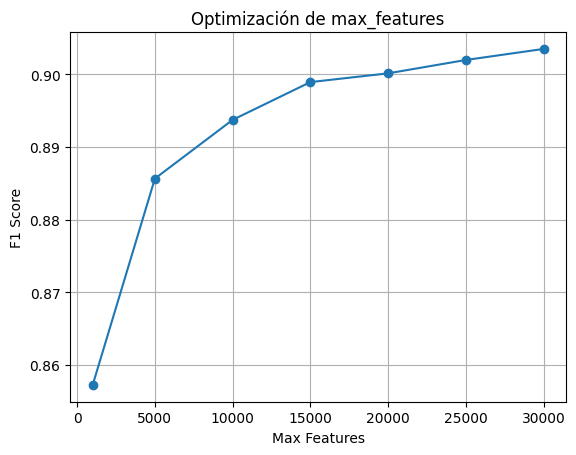

In [174]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

def test_features(feature_list, X_train, y_train, X_test, y_test):
    f1_scores = []
    for f in feature_list:
        tfidf = TfidfVectorizer(stop_words='english', max_features=f, ngram_range=(1, 3))
        xtrain = tfidf.fit_transform(X_train)
        xtest = tfidf.transform(X_test)
        
        model = LogisticRegression(max_iter=1000, C=2.465832945854912, solver="liblinear")
        model.fit(xtrain, y_train)
        f1_scores.append(f1_score(y_test, model.predict(xtest), average='weighted'))
    
    return f1_scores

features = [1000, 5000, 10000, 15000, 20000, 25000, 30000]
scores = test_features(features, X_train, y_train, X_test, y_test)

plt.plot(features, scores, marker='o')
plt.xlabel('Max Features')
plt.ylabel('F1 Score')
plt.title('Optimización de max_features')
plt.grid(True)
plt.show()

## TF-IDF

In [178]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=20000,
    ngram_range=(1,3)
)

X_tfidf_train = tfidf.fit_transform(X_train)
X_tfidf_test = tfidf.transform(X_test)

## Logistic Regression

In [179]:
lr = LogisticRegression(max_iter=1000, C=2.465832945854912,solver="liblinear")
lr.fit(X_tfidf_train, y_train)

pred_train = lr.predict(X_tfidf_train)
pred_test = lr.predict(X_tfidf_test)

results = {
    "pred_train": pred_train,
    "pred_test": pred_test,
    "accuracy_test": accuracy_score(y_test, pred_test),
    "f1_test": f1_score(y_test, pred_test, average='weighted'),
    "confusion_matrix_test": confusion_matrix(y_test, pred_test),
    "classification_report_test": classification_report(y_test, pred_test)
}

## Resultados

In [180]:
print("Max features: 20000")
print("N-gram range: (1, 3)")
print(f"Accuracy: {results['accuracy_test']:.4f}")
print(f"F1 Score: {results['f1_test']:.4f}")
print("Confusion Matrix:")
print(results['confusion_matrix_test'])
print("\n")

Max features: 20000
N-gram range: (1, 3)
Accuracy: 0.9002
F1 Score: 0.9002
Confusion Matrix:
[[5576  674]
 [ 574 5676]]




In [183]:
import pandas as pd

df_error_analysis = pd.DataFrame({
    'review_limpia': X_test,
    'sentimiento_real': y_test,
    'prediccion': pred_test
})

falsos_positivos = df_error_analysis[(df_error_analysis['sentimiento_real'] == 'negative') & 
                                     (df_error_analysis['prediccion'] == 'positive')].head(2)

falsos_negativos = df_error_analysis[(df_error_analysis['sentimiento_real'] == 'positive') & 
                                     (df_error_analysis['prediccion'] == 'negative')].head(2)

print("--- FALSOS POSITIVOS ---")
for i, rev in enumerate(falsos_positivos['review_limpia']):
    print(f"{i+1}: {rev[:300]}...\n")

print("\n\n--- FALSOS NEGATIVOS ---")
for i, rev in enumerate(falsos_negativos['review_limpia']):
    print(f"{i+1}: {rev[:300]}...\n")

--- FALSOS POSITIVOS ---
1: okay sure this film will never win an oscar citizen cane this film is not but why does every film have to be scrutinized when was the last time you saw a film that was funny not becuase it was good but because it was goofy doesnt anyone remember roger corman king of exploitationwell i had fun i like...

2: i am a longtime fan of the original of this movie bella marthamostly martha and everything that makes that movie great and enjoyable to watch is missing from this one i miss the slow pace the buildup of characters and their style in small gestures the dominance of lights and moods and moves over dia...



--- FALSOS NEGATIVOS ---
1: more and more french cinema demonstrates thats the only one able to confront hollywoods and to spend high amounts on money in their movies if bon voyage had been made in the usa no one would be surprised perfectly set in france in the  s when the nazi invasion technically irreproachable and with som...

2: wwes last ppv of   pr

___

# Modelo personalizado con la combinación "verbos - adjetivos"

In [ ]:
import spacy

nlp = spacy.load("en_core_web_sm", disable=['ner', 'parser'])

def filtrar_pos(texto):
    doc = nlp(texto)
    tokens_filtrados = [token.text for 
    token in doc if token.pos_ in ['ADJ', 'VERB']]
    return " ".join(tokens_filtrados)

print("Filtrando adjetivos y verbos...")
df['pos_filtered_reviews'] = df['cleaned_reviews'].apply(filtrar_pos)

Filtrando adjetivos y verbos...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

X_train_pos, X_test_pos, y_train, y_test = train_test_split(
    df['pos_filtered_reviews'], 
    y, 
    test_size=0.25,
    random_state=42,
    stratify=y
)

tfidf_pos = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2)   
)

X_train_tfidf = tfidf_pos.fit_transform(X_train_pos)
X_test_tfidf = tfidf_pos.transform(X_test_pos)

lr_pos = LogisticRegression(max_iter=1000, C=2.465, solver="liblinear")
lr_pos.fit(X_train_tfidf, y_train)

pred_pos = lr_pos.predict(X_test_tfidf)
print(classification_report(y_test, pred_pos))

              precision    recall  f1-score   support

    negative       0.87      0.86      0.87      6250
    positive       0.86      0.88      0.87      6250

    accuracy                           0.87     12500
   macro avg       0.87      0.87      0.87     12500
weighted avg       0.87      0.87      0.87     12500

